## Hammer Throw Distance when Including the Drag Force

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ball diameter=0.12273231093802761
distance thrown = 77.72


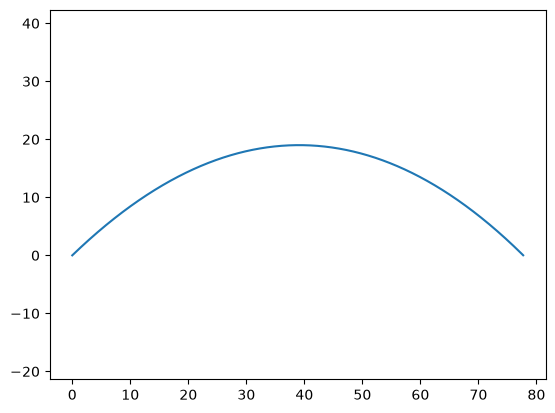

In [1]:
import math
import matplotlib.pyplot as plt

angle = 44        # angle in deg
v0 = 28.0         # initial velocity [m/s]
g = 9.81          # gravity [m/s^2]

rho_air = 1.204   # air density kg/m^3
CD = 0.45         # drag coefficient for a sphere
mass = 7.26       # ball mass [kg]
rho_steel = 7500  # ball density [kg/m^3]

dt = 0.001        # time increment size

#CD = 0

ball_radius = (3 * mass / (4 * math.pi * rho_steel))**(1/3)
print(f"Ball diameter={2*ball_radius}")
A_ball  = math.pi * ball_radius**2
x = [0.0]
y = [0.0]
vx = math.cos(angle * math.pi/180) * v0
vy = math.sin(angle * math.pi/180) * v0

while True:
    v = math.sqrt(vx**2 + vy**2)
    F_drag = 0.5 * rho_air * v**2 * CD * A_ball
    dvx = -(F_drag/mass) * (vx/v) * dt
    dvy = -((F_drag/mass) * (vy/v) + g) * dt
    vx = vx + dvx
    vy = vy + dvy

    if (y[-1] + vy * dt < 0):
        break
    x.append( x[-1] + vx * dt )
    y.append( y[-1] + vy * dt )

print(f"distance thrown = {x[-1]:.2f}")
plt.plot(x,y)
plt.axis('equal');
plt.ylim(bottom=1);

